# Wind Power Prediction using LSTM with SaDE-inspired Optimization

# 1. Import Libraries

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# 2. Load Dataset

In [ ]:


df = pd.read_csv("data/T1.csv")

# Quick look at data
df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


# 3. Data Cleaning

In [ ]:


# Rename columns for easier use
df.columns = [
    "datetime",
    "power",
    "wind_speed",
    "theoretical_power",
    "wind_direction"
]

# Convert datetime column
df["datetime"] = pd.to_datetime(df["datetime"], format="%d %m %Y %H:%M")

# Sort data by time (important for time-series)
df = df.sort_values("datetime")

# Remove missing values
df = df.dropna()

# Remove invalid values
df = df[df["power"] > 0]
df = df[df["wind_speed"] >= 0]
df = df[df["wind_speed"] <= 25]

# Remove outliers using IQR method
Q1 = df["power"].quantile(0.25)
Q3 = df["power"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["power"] >= Q1 - 1.5 * IQR) & (df["power"] <= Q3 + 1.5 * IQR)]

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Final dataset shape:", df.shape)

Final dataset shape: (39691, 5)


# 4. Basic Visualization

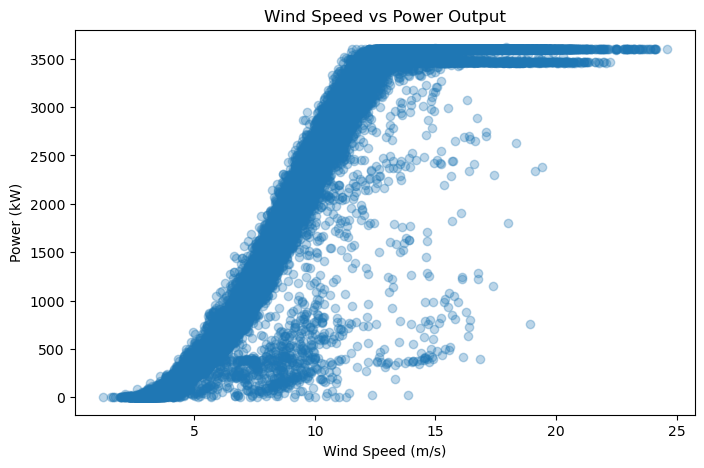

In [ ]:


plt.figure(figsize=(8,5))
plt.scatter(df["wind_speed"], df["power"], alpha=0.3)
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.title("Wind Speed vs Power Output")
plt.show()

# 5. Correlation Analysis

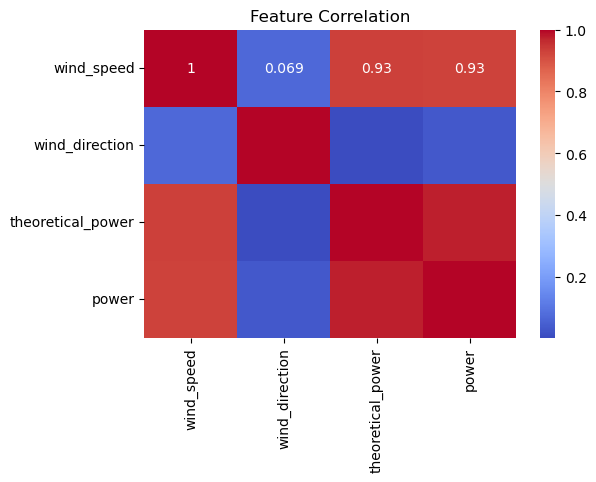

In [ ]:


plt.figure(figsize=(6,4))
sns.heatmap(
    df[["wind_speed", "wind_direction", "theoretical_power", "power"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation")
plt.show()

# 6. Time Series Plot

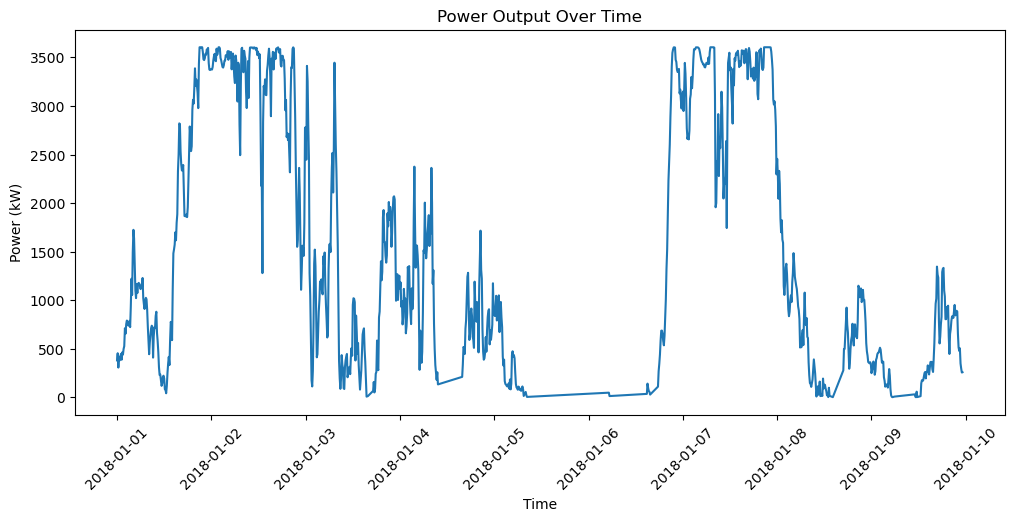

In [ ]:


plt.figure(figsize=(12,5))
plt.plot(df["datetime"][:1000], df["power"][:1000])
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("Power Output Over Time")
plt.xticks(rotation=45)
plt.show()

# 7. Feature Selection & Scaling

In [ ]:


features = ["wind_speed", "wind_direction", "theoretical_power"]
target = "power"

data = df[features + [target]]

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)

Scaled data shape: (39691, 4)


# 8. Create Sequences (LSTM Input)

In [ ]:


def create_sequences(data, seq_length=10):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])   # features
        y.append(data[i+seq_length, -1])      # target
    
    return np.array(X), np.array(y)

SEQ_LENGTH = 10

X, y = create_sequences(scaled_data, SEQ_LENGTH)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39681, 10, 3)
y shape: (39681,)


# 9. Train-Test Split

In [ ]:


split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)

Train X: (31744, 10, 3)
Test X: (7937, 10, 3)


### Why LSTM?

Wind power data is time-series in nature, meaning past values influence future output. LSTM networks are used because they can capture long-term dependencies and temporal patterns more effectively than traditional models.

# 10. Build LSTM Model

In [ ]:


model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(16),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 32)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,033 (31.38 KB)

 Trainable params: 8,033 (31.38 KB)

 Non-trainable params: 0 (0.00 B)

# 11. Train Model

In [ ]:


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0367 - val_loss: 0.0174
Epoch 2/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0131 - val_loss: 0.0153
Epoch 3/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0100 - val_loss: 0.0137
Epoch 4/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0095 - val_loss: 0.0139
Epoch 5/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0098 - val_loss: 0.0136
Epoch 6/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0094 - val_loss: 0.0137
Epoch 7/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0094 - val_loss: 0.0138
Epoch 8/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0096 - val_loss: 0.0144
Epoch 9/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0096 - val_loss: 0.0135
Epoch 10/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0092 - val_loss: 0.0135
Epoch 11/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0092 - val_loss: 0.0138
Epoch 12/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:


def build_model(units):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(units // 2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    
    model.compile(optimizer="adam", loss="mse")
    return model


results = []

# Try different configurations (like evolution search)
for units in [32, 64, 96]:
    print(f"\nTraining model with {units} units...")

    model_temp = build_model(units)

    history = model_temp.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=0
    )

    # Evaluate
    y_pred_temp = model_temp.predict(X_test, verbose=0)

    X_last = X_test[:, -1, :]
    y_test_full = np.concatenate((X_last, y_test.reshape(-1,1)), axis=1)
    y_pred_full = np.concatenate((X_last, y_pred_temp), axis=1)

    y_test_real = scaler.inverse_transform(y_test_full)[:, -1]
    y_pred_real = scaler.inverse_transform(y_pred_full)[:, -1]

    rmse_temp = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

    print(f"RMSE: {rmse_temp:.2f}")

    results.append((units, rmse_temp))


Training model with 32 units...
RMSE: 423.63

Training model with 64 units...


C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE: 433.13

Training model with 96 units...


C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE: 444.38


In [ ]:


results_df = pd.DataFrame(results, columns=["Units", "RMSE"])
print(results_df)

best_units = results_df.loc[results_df["RMSE"].idxmin()]

print("\nBest configuration:")
print(best_units)

   Units        RMSE
0     32  423.627402
1     64  433.129753
2     96  444.376226

Best configuration:
Units     32.000000
RMSE     423.627402
Name: 0, dtype: float64


# 12. Predictions

In [ ]:


y_pred = model.predict(X_test)

# Take last timestep features for inverse scaling
X_last = X_test[:, -1, :]

# Rebuild full data for inverse transform
y_test_full = np.concatenate((X_last, y_test.reshape(-1,1)), axis=1)
y_pred_full = np.concatenate((X_last, y_pred), axis=1)

# Convert back to original scale
y_test_rescaled = scaler.inverse_transform(y_test_full)[:, -1]
y_pred_rescaled = scaler.inverse_transform(y_pred_full)[:, -1]

249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


# 13. Evaluation Metrics

In [ ]:

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

nrmse = rmse / (y_test_rescaled.max() - y_test_rescaled.min())

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Normalized RMSE:", nrmse)

RMSE: 420.47335492389414
MAE: 271.6204399311365
R2 Score: 0.8858724169150773
Normalized RMSE: 0.11665428763063669


# 14. Visualization (Model Performance)

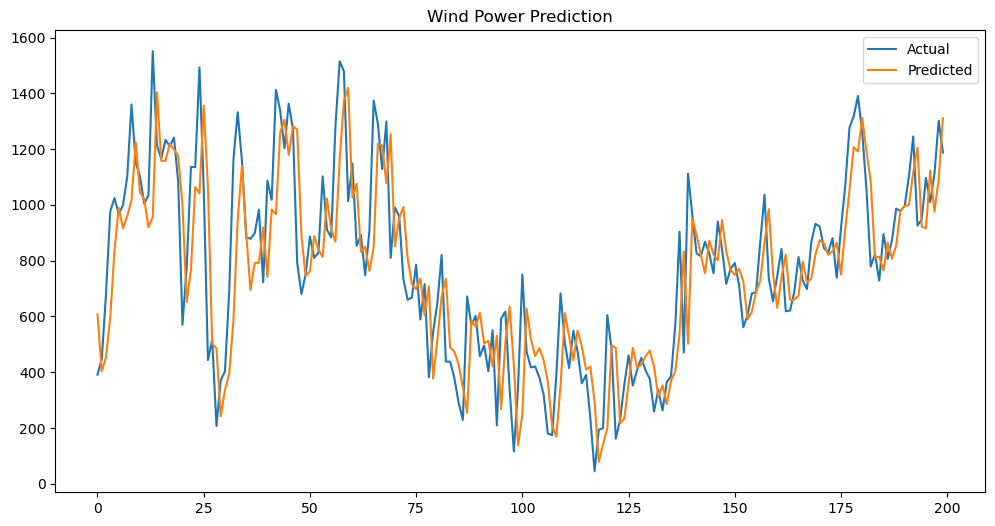

In [21]:
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled[:200], label="Actual")
plt.plot(y_pred_rescaled[:200], label="Predicted")
plt.legend()
plt.title("Wind Power Prediction")
plt.show()

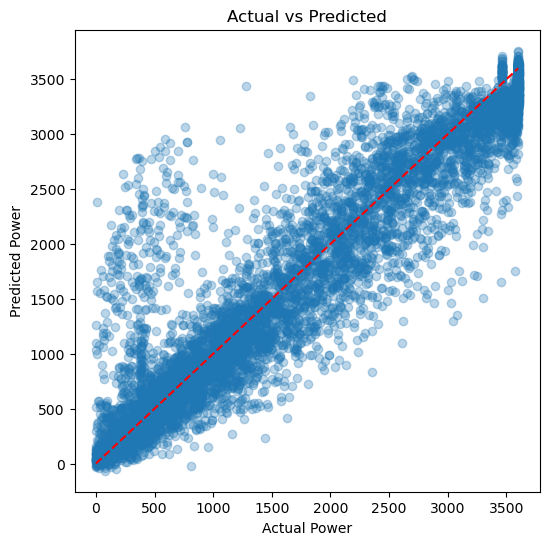

In [16]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test_rescaled, y_pred_rescaled, alpha=0.3)
plt.plot([0,3600], [0,3600], 'r--')
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted")
plt.show()

# 15. Residual Analysis

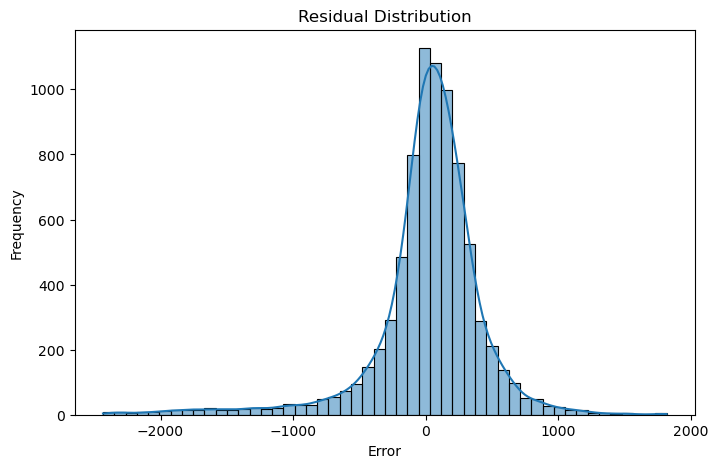

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

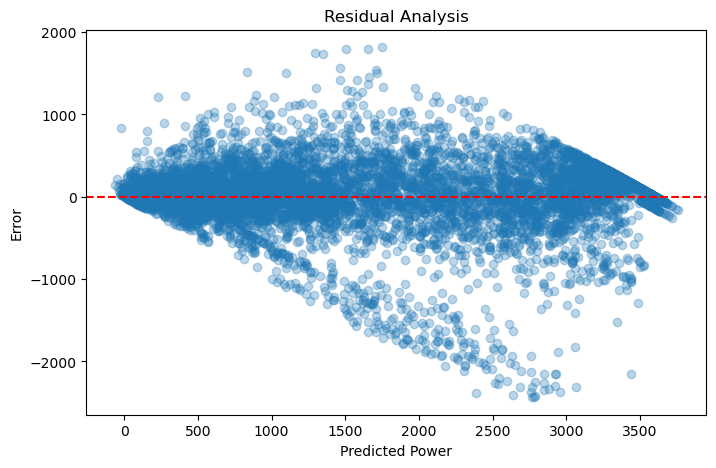

In [17]:
residuals = y_test_rescaled - y_pred_rescaled

plt.figure(figsize=(8,5))
plt.scatter(y_pred_rescaled, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Power")
plt.ylabel("Error")
plt.title("Residual Analysis")
plt.show()

# 16. Loss Curve

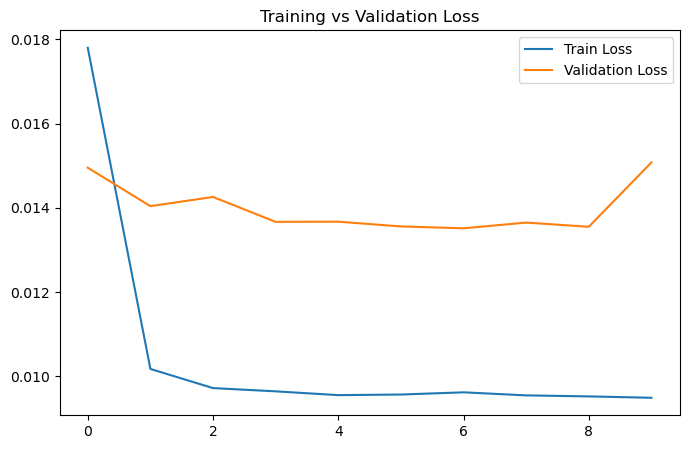

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# 17. User Input Prediction

In [ ]:


def predict_single_input(model, scaler, last_sequence, wind_speed, wind_direction, theoretical_power):

    temp = np.array([[wind_speed, wind_direction, theoretical_power, 0]])
    temp_scaled = scaler.transform(temp)[0][:3]

    new_seq = np.vstack([last_sequence[1:], temp_scaled])

    pred_scaled = model.predict(new_seq.reshape(1, SEQ_LENGTH, -1))

    full = np.array([[temp_scaled[0], temp_scaled[1], temp_scaled[2], pred_scaled[0][0]]])
    pred_real = scaler.inverse_transform(full)[0, -1]

    return pred_real


# Example
prediction = predict_single_input(
    model,
    scaler,
    X_test[-1],
    8.5,
    250,
    1500
)

print("Predicted Power:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Power: 1398.637484067293


C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [23]:
test_cases = [
    (5, 200, 500),
    (8, 250, 1500),
    (12, 270, 3000),
    (15, 300, 3500)
]

for ws, wd, tp in test_cases:
    pred = predict_single_input(model, scaler, X_test[-1], ws, wd, tp)
    print(f"Wind:{ws} → Predicted:{pred:.2f} kW")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Wind:5 → Predicted:554.80 kW
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Wind:8 → Predicted:1362.86 kW
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Wind:12 → Predicted:2704.43 kW
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Wind:15 → Predicted:3285.27 kW


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


C:\Users\Krupa Joshi\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


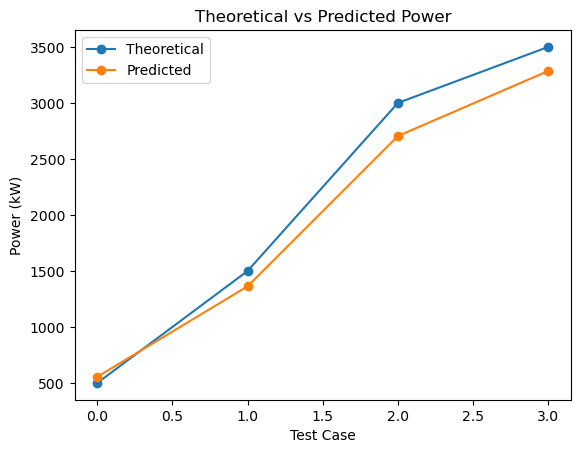

In [24]:
theoretical = [tp for _, _, tp in test_cases]
predicted = [predict_single_input(model, scaler, X_test[-1], ws, wd, tp) 
             for ws, wd, tp in test_cases]

plt.plot(theoretical, label="Theoretical", marker='o')
plt.plot(predicted, label="Predicted", marker='o')

plt.legend()
plt.title("Theoretical vs Predicted Power")
plt.xlabel("Test Case")
plt.ylabel("Power (kW)")
plt.show()